In [21]:
# Welcome to this project, 
# this is meant to just explore this dataset, displaying Homeless

In [22]:
# Set up
import pandas as pd

# Read the Data and load into the dataframe 
hospital_homeless = pd.read_csv('homeless-hospital-encounters-age-race-sex-expected-payer-statewide.csv')

# Change the types to int
for col in ["Homeless", "All"]:
    hospital_homeless[col] = hospital_homeless[col].str.replace(",", "").astype(int)

# Add a HomelessRate column
hospital_homeless["HomelessRate"] = hospital_homeless["Homeless"] / hospital_homeless["All"] * 100

hospital_homeless.head()

,EncounterType,Demographic,DemographicValue,Year,Homeless,All,HomelessRate
0,IP,AGEGROUP,0 to 18,2019-2020,1986,1263963,0.157125
1,IP,AGEGROUP,19 to 39,2019-2020,77675,1567051,4.956763
2,IP,AGEGROUP,40 to 59,2019-2020,106805,1305536,8.180931
3,IP,AGEGROUP,60+,2019-2020,50972,2897381,1.759244
4,IP,RACEGROUP,American Indian/Alaska Native,2019-2020,1744,27019,6.454717


In [23]:
# Comparing the ED and the IP for Homeless
hospital_homeless.groupby("EncounterType")[["Homeless", "All"]].sum().assign(
    HomelessRate=lambda x: x["Homeless"] / x["All"] * 100
)

,Homeless,All,HomelessRate
EncounterType,,,
ED,2633691,88847418,2.964285
IP,950029,28136003,3.376560


In [24]:
# Analyzing the Age Group

age_df = hospital_homeless[hospital_homeless["Demographic"] == "AGEGROUP"]
age_df.sort_values("HomelessRate", ascending=False)

,EncounterType,Demographic,DemographicValue,Year,Homeless,All,HomelessRate
2,IP,AGEGROUP,40 to 59,2019-2020,106805,1305536,8.180931
19,ED,AGEGROUP,40 to 59,2019-2020,290589,5314602,5.467747
1,IP,AGEGROUP,19 to 39,2019-2020,77675,1567051,4.956763
18,ED,AGEGROUP,19 to 39,2019-2020,251589,7224829,3.482283
20,ED,AGEGROUP,60+,2019-2020,109490,5029232,2.177072
3,IP,AGEGROUP,60+,2019-2020,50972,2897381,1.759244
0,IP,AGEGROUP,0 to 18,2019-2020,1986,1263963,0.157125
17,ED,AGEGROUP,0 to 18,2019-2020,6280,4642761,0.135264


In [25]:
race_df = hospital_homeless[hospital_homeless["Demographic"] == "RACEGROUP"]
race_df.sort_values("HomelessRate", ascending=False)


,EncounterType,Demographic,DemographicValue,Year,Homeless,All,HomelessRate
6,IP,RACEGROUP,Black,2019-2020,46546,562091,8.280866
23,ED,RACEGROUP,Black,2019-2020,153156,2322766,6.593690
4,IP,RACEGROUP,American Indian/Alaska Native,2019-2020,1744,27019,6.454717
21,ED,RACEGROUP,American Indian/Alaska Native,2019-2020,3684,76224,4.833123
26,ED,RACEGROUP,White,2019-2020,293809,7750715,3.790734
8,IP,RACEGROUP,Other Race/Ethnicity,2019-2020,17265,471747,3.659801
9,IP,RACEGROUP,White,2019-2020,107428,2958841,3.630746
25,ED,RACEGROUP,Other Race/Ethnicity,2019-2020,47640,1405758,3.388919
7,IP,RACEGROUP,Hispanic,2019-2020,59064,2310708,2.556100
24,ED,RACEGROUP,Hispanic,2019-2020,148944,9264900,1.607616


In [26]:
# Sorting for the Insurance
payer_df = hospital_homeless[hospital_homeless["Demographic"] == "PAYER"]
payer_df.sort_values("HomelessRate", ascending=False)

,EncounterType,Demographic,DemographicValue,Year,Homeless,All,HomelessRate
16,IP,PAYER,Uninsured,2019-2020,15175,167838,9.041457
12,IP,PAYER,Medi-Cal,2019-2020,152816,2119419,7.210278
33,ED,PAYER,Uninsured,2019-2020,84279,1550694,5.434921
29,ED,PAYER,Medi-Cal,2019-2020,421929,9365162,4.505304
14,IP,PAYER,Other Payer,2019-2020,8406,215789,3.895472
31,ED,PAYER,Other Payer,2019-2020,19700,747537,2.635321
30,ED,PAYER,Medicare,2019-2020,106465,4281073,2.486877
13,IP,PAYER,Medicare,2019-2020,48658,2463316,1.975305
15,IP,PAYER,Private Coverage,2019-2020,12486,2067829,0.603822
32,ED,PAYER,Private Coverage,2019-2020,26271,6268051,0.419125


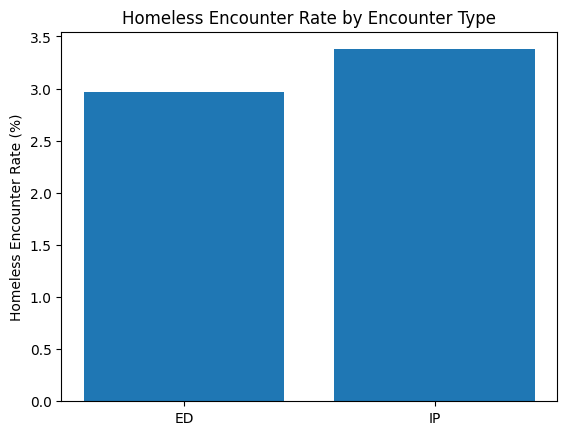

In [27]:
# Creating a Visualizations
import matplotlib.pyplot as plt

encounter_rates = (
    hospital_homeless.groupby("EncounterType")[["Homeless", "All"]]
      .sum()
      .assign(Rate=lambda x: x["Homeless"] / x["All"] * 100)
)

plt.figure()
plt.bar(encounter_rates.index, encounter_rates["Rate"])
plt.ylabel("Homeless Encounter Rate (%)")
plt.title("Homeless Encounter Rate by Encounter Type")
plt.show()

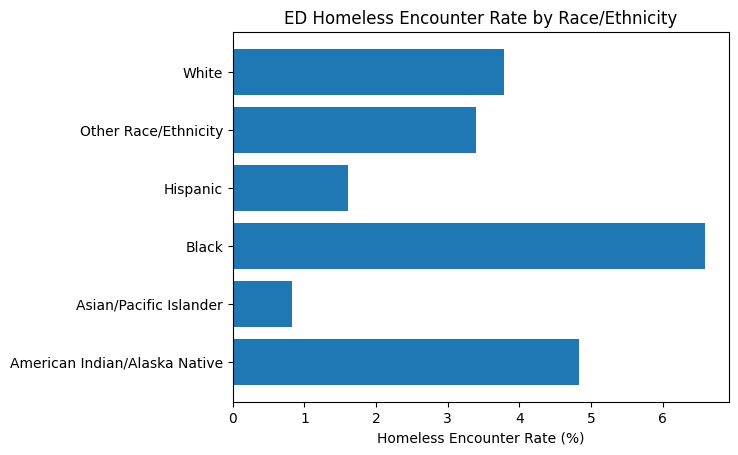

In [28]:
ed_race = race_df[race_df["EncounterType"] == "ED"]

plt.figure()
plt.barh(ed_race["DemographicValue"], ed_race["HomelessRate"])
plt.xlabel("Homeless Encounter Rate (%)")
plt.title("ED Homeless Encounter Rate by Race/Ethnicity")
plt.show()